weather forcastor

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,accuracy_score,recall_score,precision_score

import warnings
warnings.filterwarnings("ignore")

Loading data

In [57]:
data=pd.read_csv("weather_classification_data.csv")
df=pd.DataFrame(data)
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


Cleaning data

In [58]:
df=df.dropna()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

Label encoding

In [59]:
encoder=LabelEncoder()

df['Cloud Cover_encoded']=encoder.fit_transform(df['Cloud Cover'])
df['Season_encoded']=encoder.fit_transform(df['Season'])
df['Location_encoded']=encoder.fit_transform(df["Location"])
df['Weather Type_encoded']=encoder.fit_transform(df['Weather Type'])
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type,Cloud Cover_encoded,Season_encoded,Location_encoded,Weather Type_encoded
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy,3,3,1,1
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy,3,1,1,0
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny,0,1,2,3
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny,0,1,0,3
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy,2,3,2,1


Split X and y

In [60]:
features = [
    'Humidity',
    'Wind Speed',
    'Precipitation (%)',
    'Cloud Cover_encoded',
    'Atmospheric Pressure',
    'UV Index',
    'Season_encoded',
    'Visibility (km)',
    'Location_encoded'
]

#model1
X=df[features]
y=df['Weather Type_encoded']

#model2
y2=df['Temperature']

Train test spliting

In [61]:
XTrain,XTest,yTrain,yTest=train_test_split(X,y,test_size=0.3,random_state=42)

X2Train,X2Test,y2Train,y2Test=train_test_split(X,y2,random_state=42,test_size=42)

Decision Tree

In [62]:
model1=DecisionTreeClassifier()
model1.fit(XTrain,yTrain)
prediction1=model1.predict(XTest)

Model1 Evaluation

In [63]:
print(f"Accuracy: {round(accuracy_score(yTest,prediction1),2)}")

Accuracy: 0.88


Model1 Evsluation plot

   Actual  Predicted
0       3          3
1       3          3
2       3          3
3       2          2
4       3          3


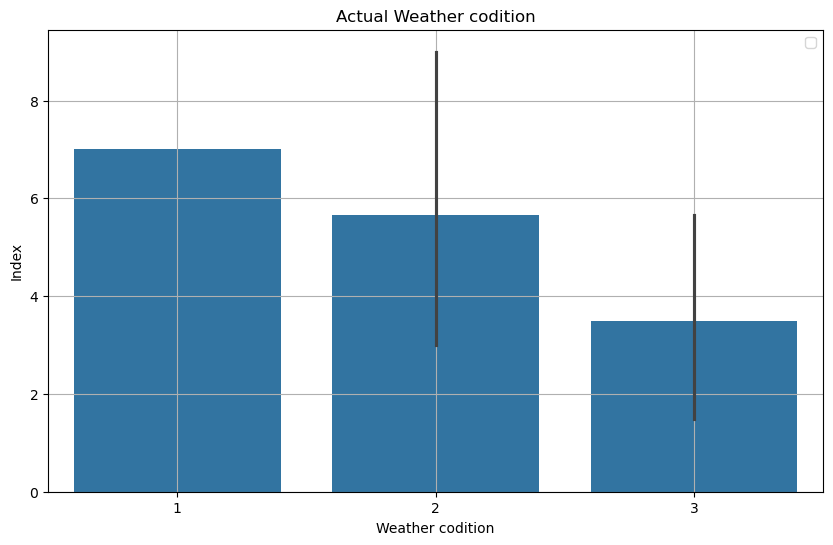

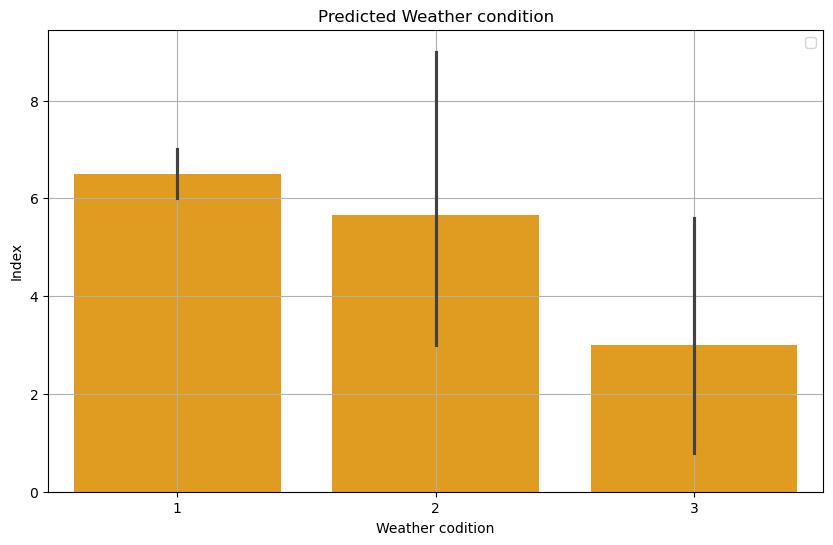

In [64]:
result=pd.DataFrame({
    "Actual": yTest.values,
    'Predicted': prediction1
})

print(result.head())
result=result.head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=result,y=result.index,x='Actual')
plt.title("Actual Weather codition")
plt.xlabel("Weather codition")
plt.ylabel("Index")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=result,y=result.index,x="Predicted",color="orange")
plt.title("Predicted Weather condition")
plt.xlabel("Weather codition")
plt.ylabel("Index")
plt.legend()
plt.grid(True)
plt.show()

Random Forest Regressor

In [65]:
model2= RandomForestRegressor()
model2.fit(X2Train,y2Train)
prediction2=model2.predict(X2Test)

model2 Evaluation

In [66]:
print(f"MAE: {round(mean_absolute_error(y2Test,prediction2),2)}")
print(f"MSE: {round(mean_squared_error(y2Test,prediction2),2)}")
print(f"RMSE: {round(np.sqrt(mean_squared_error(y2Test,prediction2)),2)}")
print(f"R2: {round(r2_score(y2Test,prediction2),2)}")

MAE: 8.18
MSE: 149.82
RMSE: 12.24
R2: 0.56


Model2 Evaluaton plot

   Actual  Predicted
0    23.0      28.88
1    62.0      47.72
2    40.0      35.91
3    -7.0      -1.29
4    21.0      47.20


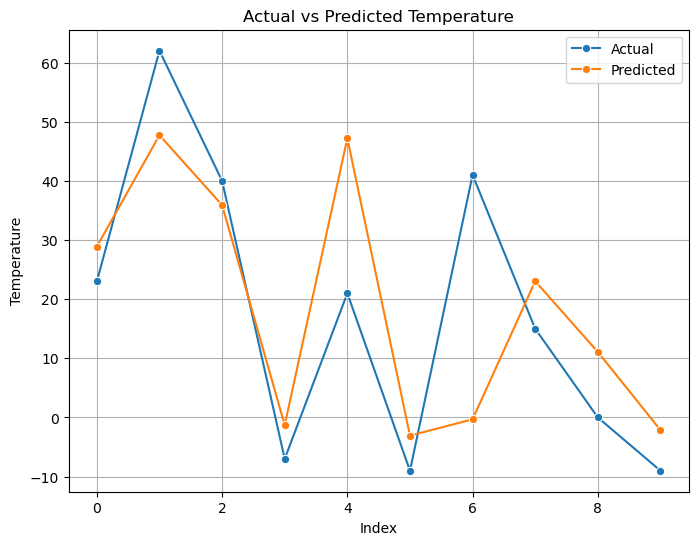

In [67]:
result2=pd.DataFrame({
    "Actual": y2Test.values,
    'Predicted': prediction2
})

print(result2.head())
result2=result2.head(10)

plt.figure(figsize=(8,6))
sns.lineplot(data=result2,x=result2.index,y='Actual',label="Actual",marker="o")
sns.lineplot(data=result2,x=result2.index,y="Predicted",label="Predicted",marker="o")
plt.title("Actual vs Predicted Temperature")
plt.xlabel("Index")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()

Inputs

In [ ]:
try:
    humidity = float(input("Enter Humidity: "))
    windSpeed = float(input("Enter Wind Speed: "))
    precipitation = float(input("Enter Precipitation (%): "))
    
    cloudCover = input(
        "Enter Cloud Cover (partly cloudy/clear/overcast/cloudy): "
    ).lower()

    atmosphericPressure = float(input("Enter Atmospheric Pressure: "))
    uvIndex = int(input("Enter UV Index: "))

    season = input(
        "Enter Season (winter/spring/autumn/summer): "
    ).lower()

    visibility = float(input("Enter Visibility (km): "))

    location = input(
        "Enter Location (inland/mountain/coastal): "
    ).lower()

    if cloudCover == "clear":
        cloudCover = 0
    elif cloudCover == "cloudy":
        cloudCover = 1
    elif cloudCover == "overcast":
        cloudCover = 2
    elif cloudCover == "partly cloudy":
        cloudCover = 3
    else:
        raise ValueError("Invalid cloud cover")

    if season == "autumn":
        season = 0
    elif season == "spring":
        season = 1
    elif season == "summer":
        season = 2
    elif season == "winter":
        season = 3
    else:
        raise ValueError("Invalid season")

    if location == "coastal":
        location = 0
    elif location == "inland":
        location = 1
    elif location == "mountain":
        location = 2
    else:
        raise ValueError("Invalid location")

    userinput = pd.DataFrame([[
        humidity,
        windSpeed,
        precipitation,
        cloudCover,
        atmosphericPressure,
        uvIndex,
        season,
        visibility,
        location
    ]], columns=X.columns)

    output1 = model1.predict(userinput)
    output2 = model2.predict(userinput)

    if output1[0]==0:
        weather="Cloudy"
    elif output1[0]==1:
        weather="Rainly"
    elif output1[0]==2:
        weather="Snowy"
    elif output1[0]==3:
        weather="Sunny"

    print(f"Predicted Weather Type: {weather}")
    print(f"Predicted Temperature: {round(output2[0], 2)} °C")

except Exception as e:
    print("An error occurred:", e)

Predicted Weather Type: Sunny
Predicted Temperature: 39.82 °C
